In [59]:
# Install required machine learning and visualization libraries
!pip install pandas numpy matplotlib seaborn scikit-learn -q

In [60]:
# Import libraries required for data handling, visualization and clustering
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

In [61]:
# Upload country metrics CSV file into Colab environment

from google.colab import files
uploaded = files.upload()

Saving Country-data.csv to Country-data (2).csv


In [62]:
# Load uploaded CSV dataset

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [63]:
# Data Cleaning

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Display dataset information
print("Dataset Shape:")
print(df.shape)

# Convert all possible columns into numeric format

for col in df.columns:
    if col != 'country':
        df[col]=pd.to_numeric(df[col],errors='coerce')


# Fill missing numeric values with median
for col in df.columns:
    if col != 'country':
        df[col].fillna(df[col].median(),inplace=True)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

Dataset Shape:
(167, 10)

Missing Values After Cleaning:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


In [64]:
#checking dataset
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [65]:
# Feature Preparation

# Store country names separately for final analysis
country = df['country']

# Remove country identifier column
X = df.drop('country', axis=1)

# Scale all numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled Data Shape:")
print(X_scaled.shape)

Scaled Data Shape:
(167, 9)


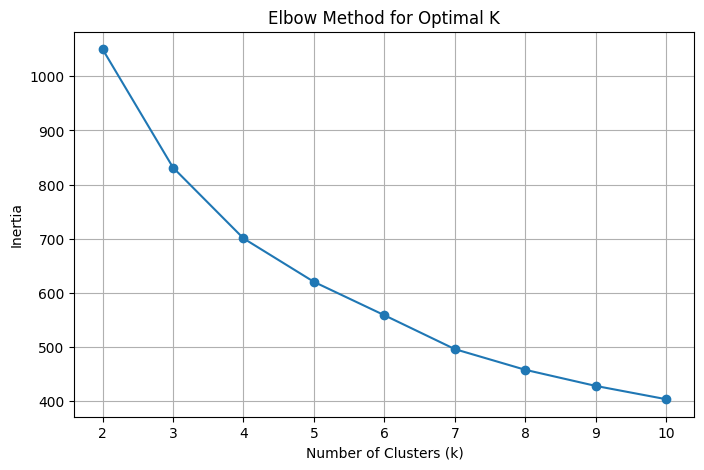

In [66]:
# finding optimal cluster count

# Store inertia values
inertia = []

# Test cluster values from 2 to 10
for k in range(2,11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)


# Ploting elbow curve
plt.figure(figsize=(8,5))
plt.plot(range(2,11),inertia,marker='o')

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")

plt.title("Elbow Method for Optimal K")

plt.grid(True)

plt.show()

In [67]:
#K-Mean model

# Based on elbow analysis we select 3 clusters
best_k = 3
kmeans = KMeans(n_clusters=best_k,random_state=42,n_init=10)

# Train model
kmeans_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels
df['KMeans_Cluster'] = kmeans_labels

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,KMeans_Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2


In [68]:
# Model Evaluation

# Calculate silhouette score
score = silhouette_score(X_scaled,kmeans_labels)
print("K-Means Silhouette Score:",round(score,4))

K-Means Silhouette Score: 0.2833


In [69]:
#DBSCAN

# Create DBSCAN clustering model

dbscan = DBSCAN(eps=1.5,min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Add DBSCAN result
df['DBSCAN_Cluster'] = dbscan_labels

print("DBSCAN Cluster Counts:")

print(df['DBSCAN_Cluster'].value_counts())

DBSCAN Cluster Counts:
DBSCAN_Cluster
 0    137
-1     30
Name: count, dtype: int64


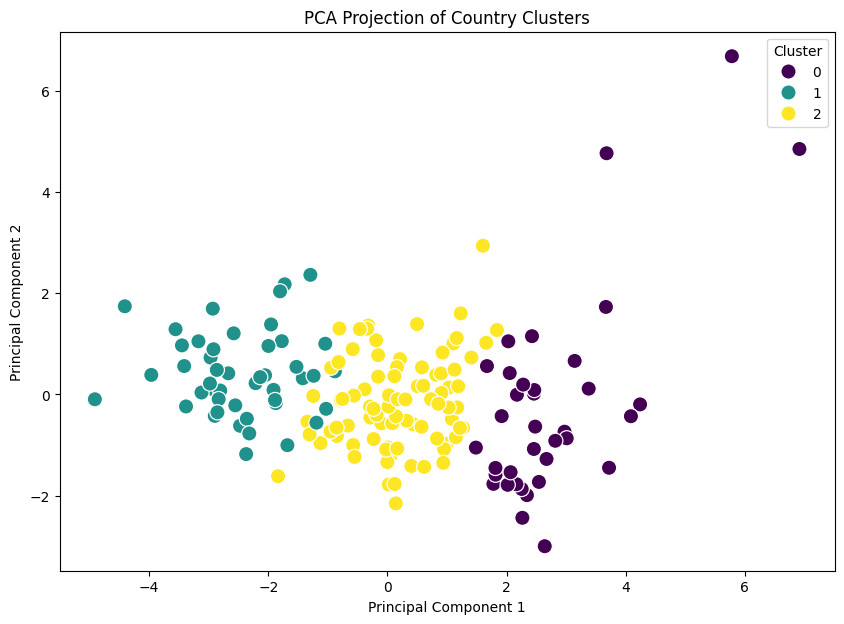

In [70]:
#PCA Visualization

# Reduce dimensions from multiple features to 2 components

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(X_pca,columns=['PC1','PC2'])
pca_df['Cluster'] = kmeans_labels

plt.figure(figsize=(10,7))
sns.scatterplot(data=pca_df,x='PC1',y='PC2', hue='Cluster',palette='viridis',s=120)
plt.title("PCA Projection of Country Clusters")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [71]:
# Cluster analaysis

# Add country names back
cluster_data = df.copy()

# Calculate cluster averages
cluster_summary = (cluster_data.groupby('KMeans_Cluster').mean(numeric_only=True))
cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,DBSCAN_Cluster
KMeans_Cluster,,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444,-0.250000
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979,-0.340426
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381,-0.059524


In [72]:
#identify countries needing aids

# Select required columns first
priority_countries = poor_countries[
    [
        'country',
        'child_mort',
        'income',
        'gdpp',
        'life_expec'
    ]
]


# Sort the dataframe by GDP (lowest first)
priority_countries = priority_countries.sort_values(
    by='gdpp',
    ascending=True
)


# Display top 15 countries needing aid
print("Countries needing highest priority:\n")

priority_countries.head(15)

Countries needing highest priority:



,country,child_mort,income,gdpp,life_expec
26,Burundi,93.6,764,231,57.7
88,Liberia,89.3,700,327,60.8
37,"Congo, Dem. Rep.",116.0,609,334,57.5
112,Niger,123.0,814,348,58.8
132,Sierra Leone,160.0,1220,399,55.0
93,Madagascar,62.2,1390,413,60.8
106,Mozambique,101.0,918,419,54.5
31,Central African Republic,149.0,888,446,47.5
94,Malawi,90.5,1030,459,53.1
50,Eritrea,55.2,1420,482,61.7


In [73]:
# Final Observation

print(
"""
OBSERVATIONS:

1. Countries in the high mortality cluster have higher child mortality rates,
   lower life expectancy and require immediate healthcare support.

2. The economically developed cluster contains countries with high GDP per capita,
   higher income levels and better health indicators.

3. Low-development countries generally show low GDP, low income,
   high fertility rates and poor healthcare infrastructure.

4. K-Means successfully separates countries into three development groups:
   developed, developing and underdeveloped nations.

5. HELP International should prioritize countries belonging to the
   underdeveloped cluster for maximum humanitarian impact.
"""
)


OBSERVATIONS:

1. Countries in the high mortality cluster have higher child mortality rates,
   lower life expectancy and require immediate healthcare support.

2. The economically developed cluster contains countries with high GDP per capita,
   higher income levels and better health indicators.

3. Low-development countries generally show low GDP, low income,
   high fertility rates and poor healthcare infrastructure.

4. K-Means successfully separates countries into three development groups:
   developed, developing and underdeveloped nations.

5. HELP International should prioritize countries belonging to the
   underdeveloped cluster for maximum humanitarian impact.



In [74]:
# Final silhouette score validation

sil_score = silhouette_score(X_scaled,df['KMeans_Cluster'])
print("="*50)
print("MODEL CLUSTERING EVALUATION")
print("="*50)
print(f"Silhouette Score: {sil_score:.4f}")


if sil_score > 0:
    print("Status: PASS - Clusters have meaningful separation")
else:
    print("Status: Review cluster configuration")

MODEL CLUSTERING EVALUATION
Silhouette Score: 0.2833
Status: PASS - Clusters have meaningful separation


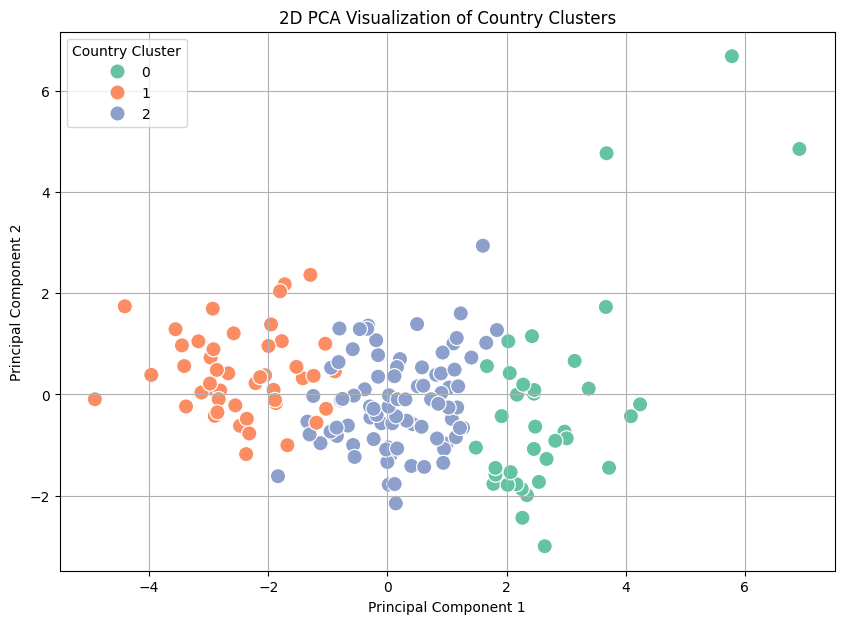

PCA Plot Generated Successfully


In [75]:
# PCA visualization of country clusters
pca = PCA(n_components=2,random_state=42)
pca_result = pca.fit_transform(X_scaled)

pca_plot = pd.DataFrame(pca_result,columns=['PC1','PC2'])
pca_plot['Cluster'] = df['KMeans_Cluster']

plt.figure(figsize=(10,7))
sns.scatterplot(data=pca_plot,x='PC1',y='PC2',hue='Cluster',palette='Set2',s=120)
plt.title("2D PCA Visualization of Country Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Country Cluster")
plt.grid(True)
plt.show()

print("PCA Plot Generated Successfully")

In [76]:
# Section 14: Socio-economic observations

print(
"""
SECTION 14: FINAL OBSERVATIONS

1. High mortality countries:
   The cluster with the highest child mortality rate contains countries
   with poor healthcare facilities, lower life expectancy and higher
   fertility rates. These countries require immediate humanitarian support.

2. Top-tier economic zones:
   Developed clusters contain countries with higher GDP per capita,
   higher income levels and stronger healthcare systems. These countries
   have better living standards and require less emergency assistance.

3. Low-development areas:
   Countries with low GDP, low income and high child mortality are
   categorized as underdeveloped regions. They should receive priority
   funding from HELP International.

4. Socio-economic relationship:
   Economic indicators such as GDP and income show a strong relationship
   with health indicators. Countries with stronger economies generally
   have better life expectancy and lower mortality rates.

5. Aid recommendation:
   HELP International should focus the $10 million funding on countries
   belonging to the low-development cluster to maximize social impact.
"""
)


SECTION 14: FINAL OBSERVATIONS

1. High mortality countries:
   The cluster with the highest child mortality rate contains countries
   with poor healthcare facilities, lower life expectancy and higher
   fertility rates. These countries require immediate humanitarian support.

2. Top-tier economic zones:
   Developed clusters contain countries with higher GDP per capita,
   higher income levels and stronger healthcare systems. These countries
   have better living standards and require less emergency assistance.

3. Low-development areas:
   Countries with low GDP, low income and high child mortality are
   categorized as underdeveloped regions. They should receive priority
   funding from HELP International.

4. Socio-economic relationship:
   Economic indicators such as GDP and income show a strong relationship
   with health indicators. Countries with stronger economies generally
   have better life expectancy and lower mortality rates.

5. Aid recommendation:
   HELP Internationa